In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project src to path so we can use the ccn_dashboard data utilities
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

In [2]:
from ccn_dashboard.data_provider import ensure_synthesis_data_dir

# Locates the CCN synthesis data directory, downloading it on first run if needed.
# Files are cached at files/current/CCN_synthesis/ relative to the project root.
location = ensure_synthesis_data_dir()
DATA_DIR = location.path
print(location.message)
print(f"Data directory: {DATA_DIR}")
print(f"Files: {[f.name for f in DATA_DIR.iterdir() if f.suffix == '.csv']}")

Using CCN synthesis data from /home/klewtak/NASA/CCN-Data-Library/files/current/CCN_synthesis
Data directory: /home/klewtak/NASA/CCN-Data-Library/files/current/CCN_synthesis
Files: ['CCN_cores.csv', 'CCN_species.csv', 'CCN_study_citations.csv', 'CCN_depthseries.csv', 'CCN_methods.csv', 'CCN_impacts.csv', 'CCN_sites.csv']


In [ ]:
# CCN Cores dataset
cores = pd.read_csv(DATA_DIR / "CCN_cores.csv")

print(f"Shape: {cores.shape}")
print(f"\nColumns ({len(cores.columns)}):\n{list(cores.columns)}")
cores.head()

Shape: (16715, 39)

Columns (39):
['study_id', 'site_id', 'core_id', 'year', 'month', 'day', 'core_notes', 'latitude', 'longitude', 'position_accuracy', 'position_method', 'position_notes', 'elevation', 'elevation_datum', 'elevation_accuracy', 'elevation_method', 'elevation_notes', 'salinity_class', 'salinity_method', 'salinity_notes', 'vegetation_class', 'vegetation_method', 'vegetation_notes', 'inundation_class', 'inundation_method', 'inundation_notes', 'core_length_flag', 'pb210_cic_accretion_rate', 'pb210_cic_accretion_rate_se', 'pb210_cic_notes', 'pb210_cic_max_depth', 'pb210_cic_r2', 'country', 'admin_division', 'habitat', 'stocks_qual_code', 'dates_qual_code', 'elevation_qual_code', 'max_depth']


/tmp/ipykernel_8606/1592935932.py:2: DtypeWarning: Columns (19,29) have mixed types. Specify dtype option on import or set low_memory=False.
  cores = pd.read_csv(DATA_DIR / "CCN_cores.csv")


,study_id,site_id,core_id,year,month,day,core_notes,latitude,longitude,position_accuracy,...,pb210_cic_notes,pb210_cic_max_depth,pb210_cic_r2,country,admin_division,habitat,stocks_qual_code,dates_qual_code,elevation_qual_code,max_depth
0,Yellen_2024,Bald Head Point,BHP001_16m_core,2021.0,2.0,NaN,Field samples were collected between 2020-06-0...,43.81595,-69.79872,NaN,...,NaN,NaN,NaN,United States,Maine,marsh,C2,NaN,NaN,200.0
1,Yellen_2024,Bald Head Point,BHP002_16m_core,2021.0,2.0,NaN,Field samples were collected between 2020-06-0...,43.81700,-69.79689,NaN,...,NaN,NaN,NaN,United States,Maine,marsh,C2,NaN,NaN,200.0
2,Yellen_2024,Bald Head Point,BHP004_16m_core,2021.0,2.0,NaN,Field samples were collected between 2020-06-0...,43.82450,-69.79278,NaN,...,NaN,NaN,NaN,United States,Maine,marsh,C2,NaN,NaN,150.0
3,Yellen_2024,Barn Island,BRN_1_core,2021.0,2.0,NaN,Field samples were collected between 2020-06-0...,41.26903,-72.75480,NaN,...,NaN,NaN,NaN,United States,Connecticut,marsh,C2,NaN,NaN,110.0
4,Yellen_2024,Barn Island,BRN_2_core,2021.0,2.0,NaN,Field samples were collected between 2020-06-0...,41.26983,-72.75560,NaN,...,NaN,NaN,NaN,United States,Connecticut,marsh,NaN,NaN,NaN,100.0


In [4]:
cores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   study_id                     16715 non-null  object 
 1   site_id                      16714 non-null  object 
 2   core_id                      16715 non-null  object 
 3   year                         14233 non-null  float64
 4   month                        6984 non-null   float64
 5   day                          5943 non-null   float64
 6   core_notes                   3736 non-null   object 
 7   latitude                     16712 non-null  float64
 8   longitude                    16712 non-null  float64
 9   position_accuracy            489 non-null    float64
 10  position_method              10807 non-null  object 
 11  position_notes               9011 non-null   object 
 12  elevation                    2826 non-null   float64
 13  elevation_datum 

In [ ]:
# CCN Depthseries dataset
depthseries = pd.read_csv(DATA_DIR / "CCN_depthseries.csv")

print(f"Shape: {depthseries.shape}")
print(f"\nColumns ({len(depthseries.columns)}):\n{list(depthseries.columns)}")
depthseries.head()

Shape: (117518, 49)

Columns (49):
['study_id', 'site_id', 'core_id', 'method_id', 'depth_min', 'depth_max', 'representative_depth_min', 'representative_depth_max', 'sample_id', 'dry_bulk_density', 'fraction_organic_matter', 'fraction_carbon', 'compaction_fraction', 'compaction_notes', 'cs137_peak_age', 'cs137_activity', 'cs137_activity_se', 'cs137_unit', 'excess_pb210_activity', 'excess_pb210_activity_se', 'total_pb210_activity', 'total_pb210_activity_se', 'pb210_unit', 'ra226_activity', 'ra226_activity_se', 'ra226_unit', 'pb214_activity', 'pb214_activity_se', 'pb214_unit', 'bi214_activity', 'bi214_activity_se', 'bi214_unit', 'c14_age', 'c14_age_se', 'c14_material', 'c14_notes', 'delta_c13', 'be7_activity', 'be7_activity_se', 'be7_unit', 'marker_date', 'marker_date_se', 'marker_type', 'marker_notes', 'age', 'age_min', 'age_max', 'age_se', 'depth_interval_notes']


/tmp/ipykernel_8606/2181070406.py:2: DtypeWarning: Columns (8,13,17,22,25,28,31,34,35,39,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  depthseries = pd.read_csv(DATA_DIR / "CCN_depthseries.csv")


,study_id,site_id,core_id,method_id,depth_min,depth_max,representative_depth_min,representative_depth_max,sample_id,dry_bulk_density,...,be7_unit,marker_date,marker_date_se,marker_type,marker_notes,age,age_min,age_max,age_se,depth_interval_notes
0,Yellen_2024,SR,SR_BD_1,surface_sample,0.0,10.0,NaN,NaN,NaN,0.16268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Yellen_2024,SR,SR_BD_2,surface_sample,0.0,10.0,NaN,NaN,NaN,0.13158,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Yellen_2024,SR,SR_BD_3,surface_sample,0.0,10.0,NaN,NaN,NaN,0.18421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Yellen_2024,SR,SR_BD_4,surface_sample,0.0,10.0,NaN,NaN,NaN,0.17464,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Yellen_2024,SR,SR_BD_9,surface_sample,0.0,10.0,NaN,NaN,NaN,0.16029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
depthseries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117518 entries, 0 to 117517
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   study_id                  117518 non-null  object 
 1   site_id                   117511 non-null  object 
 2   core_id                   117518 non-null  object 
 3   method_id                 114899 non-null  object 
 4   depth_min                 115714 non-null  float64
 5   depth_max                 115711 non-null  float64
 6   representative_depth_min  2972 non-null    float64
 7   representative_depth_max  2967 non-null    float64
 8   sample_id                 9756 non-null    object 
 9   dry_bulk_density          99924 non-null   float64
 10  fraction_organic_matter   67255 non-null   float64
 11  fraction_carbon           50197 non-null   float64
 12  compaction_fraction       2220 non-null    float64
 13  compaction_notes          8584 non-null    o

In [ ]:
# Numeric summaries
print("=== Cores numeric summary ===")
display(cores.describe())

print("\n=== Depthseries numeric summary ===")
display(depthseries.describe())

=== Cores numeric summary ===


,year,month,day,latitude,longitude,position_accuracy,elevation,elevation_accuracy,pb210_cic_accretion_rate,pb210_cic_accretion_rate_se,pb210_cic_max_depth,pb210_cic_r2,max_depth
count,14233.000000,6984.000000,5943.000000,16712.000000,16712.000000,489.000000,2826.000000,287.000000,82.000000,43.000000,81.000000,82.000000,16662.000000
mean,2013.674629,6.068729,13.657076,18.537500,-14.651105,7.539963,-0.892649,0.062519,0.573366,0.988605,28.030420,0.752561,69.406421
std,6.350223,3.102456,7.625171,28.274148,79.773449,15.442826,6.727968,0.230065,0.646122,2.945786,13.805549,0.266643,83.737209
min,1960.000000,1.000000,1.000000,-51.826230,-157.811985,0.001000,-33.109400,0.002000,0.040000,0.070000,6.630000,0.060000,0.000000
25%,2012.000000,4.000000,8.000000,-0.632361,-82.731451,3.000000,0.150000,0.014000,0.190000,0.165000,18.420000,0.652500,15.000000
50%,2014.000000,5.000000,13.000000,27.743075,-6.283005,5.000000,0.435000,0.014000,0.375000,0.310000,22.440000,0.880000,30.000000
75%,2018.000000,9.000000,18.000000,39.900000,32.424564,10.000000,1.008000,0.040000,0.667500,0.525000,39.000000,0.940000,100.000000
max,2024.000000,12.000000,31.000000,72.427980,178.500000,100.000000,9.500000,2.512000,4.000000,16.300000,59.000000,1.000000,894.000000



=== Depthseries numeric summary ===


,depth_min,depth_max,representative_depth_min,representative_depth_max,dry_bulk_density,fraction_organic_matter,fraction_carbon,compaction_fraction,cs137_peak_age,cs137_activity,...,c14_age_se,delta_c13,be7_activity,be7_activity_se,marker_date,marker_date_se,age,age_min,age_max,age_se
count,115714.000000,115711.000000,2972.000000,2967.000000,99924.000000,67255.000000,50197.000000,2220.000000,1092.000000,1.649100e+04,...,289.000000,3760.000000,2730.000000,2660.000000,51.000000,21.000000,3788.000000,800.000000,800.000000,2365.000000
mean,35.558424,43.703145,31.115410,75.413886,0.623366,0.197797,0.084697,0.273377,1963.968864,1.019614e+01,...,49.076703,-21.754671,0.445328,0.430662,1964.892157,7.857143,1415.382472,1091.208750,1177.158750,22.803302
std,60.286276,66.048260,36.309523,72.718454,0.539164,0.209309,0.092906,0.318873,0.173764,1.202515e+02,...,160.767749,5.532004,2.756664,6.527191,56.382561,6.223228,936.057166,998.667672,1029.290468,688.537189
min,0.000000,0.000000,0.000000,2.000000,-81.150000,-0.053100,-0.037948,0.000000,1963.000000,-3.097150e+01,...,0.000000,-44.158000,0.000000,0.000000,1780.000000,1.000000,-65.000000,-61.000000,-19.000000,0.000000
25%,6.000000,12.000000,0.000000,30.000000,0.254695,0.038240,0.018900,0.009300,1964.000000,2.796863e-08,...,15.000000,-26.691150,0.000000,0.000000,1954.500000,5.000000,136.500000,110.000000,163.000000,1.000000
50%,20.000000,25.000000,21.000000,50.000000,0.520000,0.116000,0.049400,0.071000,1964.000000,2.980000e-01,...,26.000000,-23.600221,0.000000,0.000000,1983.000000,5.000000,1940.000000,982.500000,1262.500000,2.200000
75%,42.000000,50.000000,50.000000,100.000000,0.889000,0.290000,0.117700,0.663162,1964.000000,1.960000e+00,...,35.000000,-16.410000,0.000000,0.000000,2002.000000,6.000000,1984.525000,1951.500000,1977.000000,5.900000
max,2022.000000,894.000000,298.000000,427.000000,11.264000,1.592684,1.097000,1.003714,1964.000000,1.127800e+04,...,1600.000000,-9.143432,50.330000,294.830000,2010.000000,20.000000,5818.000000,5143.000000,5502.000000,33469.306119


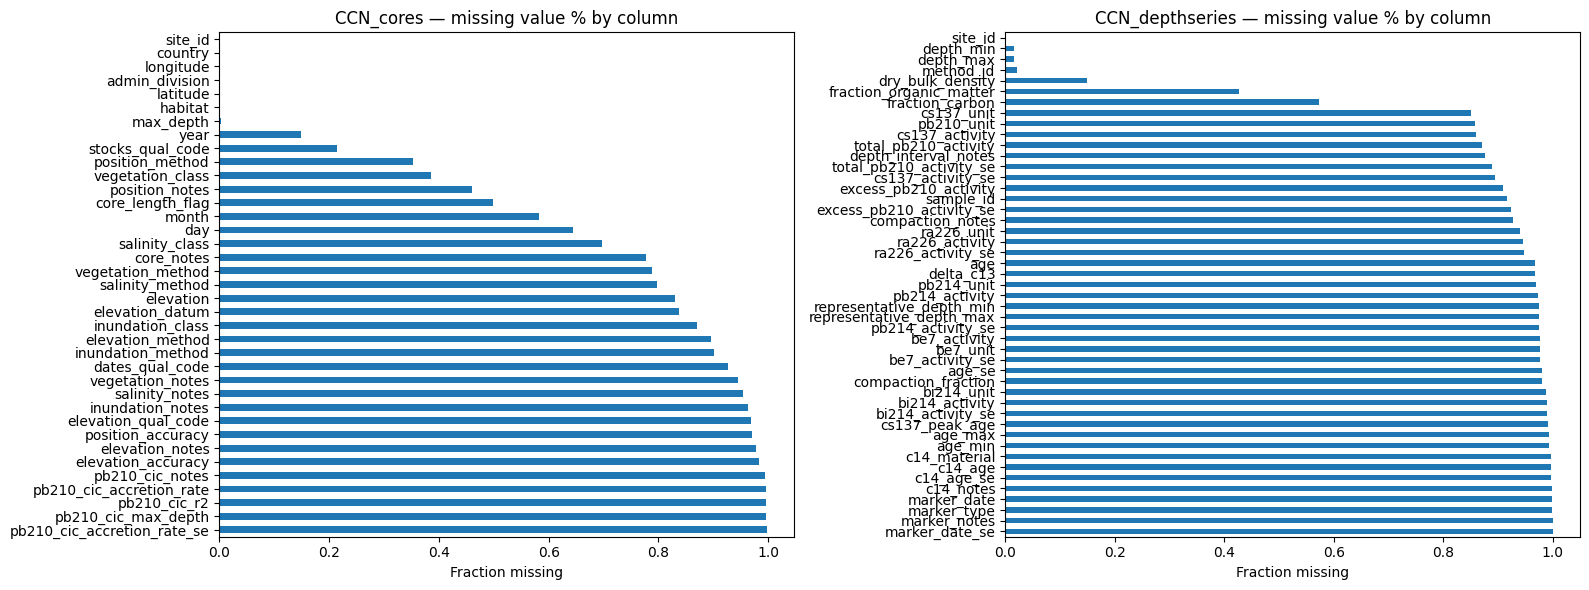

In [ ]:
# Missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, title) in zip(
    axes, [(cores, "CCN_cores"), (depthseries, "CCN_depthseries")]
):
    missing_pct = df.isnull().mean().sort_values(ascending=False)
    missing_pct[missing_pct > 0].plot.barh(ax=ax)
    ax.set_title(f"{title} — missing value % by column")
    ax.set_xlabel("Fraction missing")

plt.tight_layout()
plt.show()

Total studies: 550
Total unique cores: 16690


/tmp/ipykernel_8606/2410969220.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


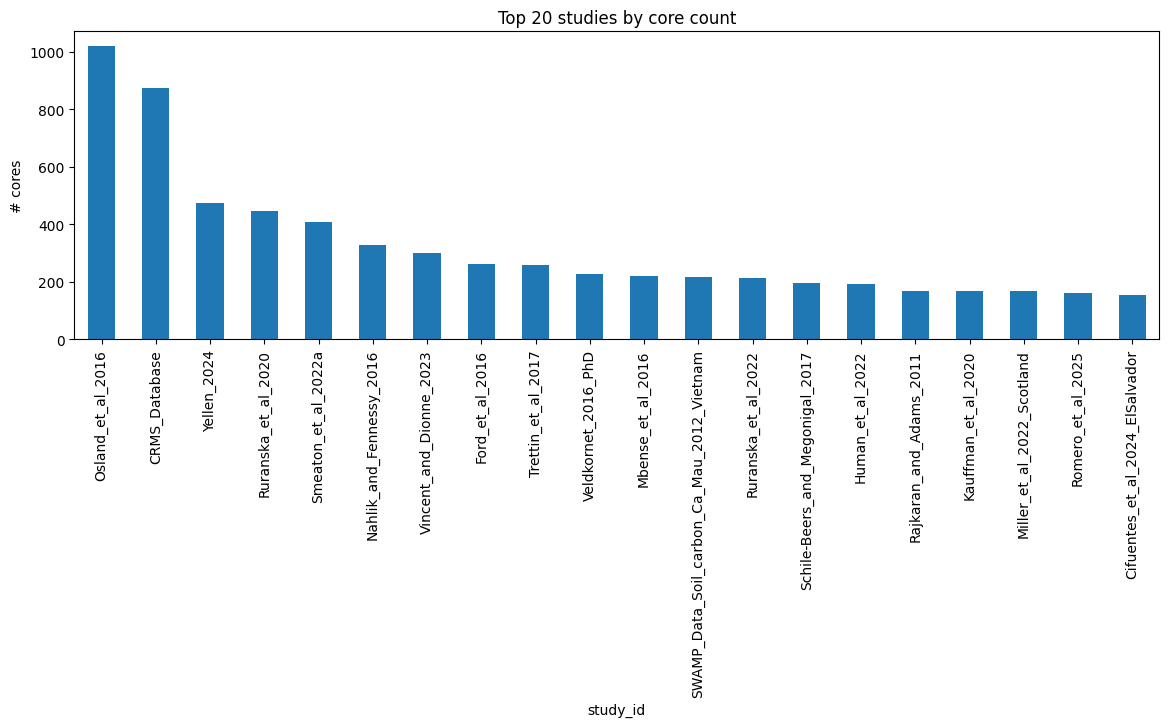

In [9]:
# Join summary: cores per study
cores_per_study = (
    cores.groupby("study_id")["core_id"].nunique().sort_values(ascending=False)
)
print(f"Total studies: {cores_per_study.shape[0]}")
print(f"Total unique cores: {cores['core_id'].nunique()}")

cores_per_study.head(20).plot.bar(figsize=(14, 4), title="Top 20 studies by core count")
plt.ylabel("# cores")
plt.tight_layout()
plt.show()

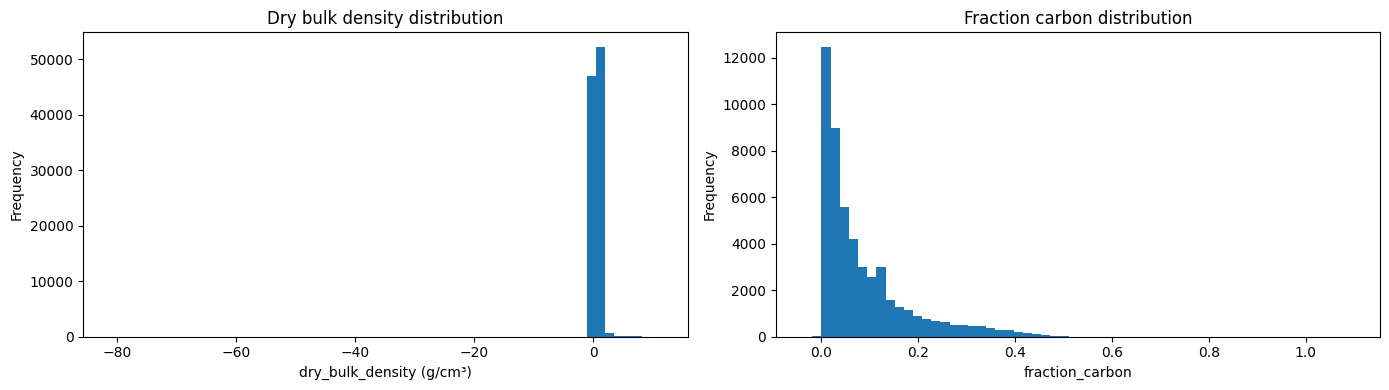

In [10]:
# Key depthseries distributions: bulk density & fraction carbon
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

depthseries["dry_bulk_density"].dropna().plot.hist(bins=60, ax=axes[0])
axes[0].set_title("Dry bulk density distribution")
axes[0].set_xlabel("dry_bulk_density (g/cm³)")

depthseries["fraction_carbon"].dropna().plot.hist(bins=60, ax=axes[1])
axes[1].set_title("Fraction carbon distribution")
axes[1].set_xlabel("fraction_carbon")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- US biome location maps: mangrove, seagrass, marsh ---
BIOMES = {
    "mangrove": {"color": "#2ca02c", "symbol": "circle"},
    "seagrass": {"color": "#1f77b4", "symbol": "circle"},
    "marsh": {"color": "#8c564b", "symbol": "circle"},
}

us_cores = cores[
    (cores["country"] == "United States")
    & cores["latitude"].notna()
    & cores["longitude"].notna()
].copy()

fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=[
        f"{b.capitalize()} sites (n={len(us_cores[us_cores['habitat']==b])})"
        for b in BIOMES
    ],
    specs=[[{"type": "geo"}], [{"type": "geo"}], [{"type": "geo"}]],
    vertical_spacing=0.05,
)

geo_common = dict(
    scope="usa",
    showland=True,
    landcolor="#f5f5f0",
    showlakes=True,
    lakecolor="#c6dcec",
    showcoastlines=True,
    coastlinecolor="#888",
    showsubunits=True,
    subunitcolor="#ccc",
    projection_type="albers usa",
    bgcolor="#eaf2fb",
    countrycolor="#aaa",
    showframe=False,
)

for row, (biome, style) in enumerate(BIOMES.items(), start=1):
    subset = us_cores[us_cores["habitat"] == biome]
    fig.add_trace(
        go.Scattergeo(
            lat=subset["latitude"],
            lon=subset["longitude"],
            mode="markers",
            marker=dict(
                size=5,
                color=style["color"],
                opacity=0.65,
                line=dict(width=0.3, color="white"),
            ),
            text=subset["study_id"] + "<br>" + subset["core_id"],
            hovertemplate="%{text}<br>(%{lat:.3f}, %{lon:.3f})<extra></extra>",
            name=biome.capitalize(),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig.update_geos(row=row, col=1, **geo_common)

fig.update_layout(
    title_text="CCN Synthesis — US Core Locations by Biome",
    title_x=0.5,
    height=1050,
    margin=dict(l=0, r=0, t=60, b=10),
    paper_bgcolor="white",
)

fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Global biome location maps: mangrove, seagrass, marsh ---
global_cores = cores[cores["latitude"].notna() & cores["longitude"].notna()].copy()

fig_global = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=[
        f"{b.capitalize()} sites — global (n={len(global_cores[global_cores['habitat']==b])})"
        for b in BIOMES
    ],
    specs=[[{"type": "geo"}], [{"type": "geo"}], [{"type": "geo"}]],
    vertical_spacing=0.04,
)

geo_global = dict(
    showland=True,
    landcolor="#f0ede8",
    showocean=True,
    oceancolor="#d6eaf8",
    showlakes=True,
    lakecolor="#d6eaf8",
    showcoastlines=True,
    coastlinecolor="#999",
    showsubunits=False,
    showcountries=True,
    countrycolor="#bbb",
    showframe=False,
    projection_type="natural earth",
    bgcolor="white",
)

for row, (biome, style) in enumerate(BIOMES.items(), start=1):
    subset = global_cores[global_cores["habitat"] == biome]
    fig_global.add_trace(
        go.Scattergeo(
            lat=subset["latitude"],
            lon=subset["longitude"],
            mode="markers",
            marker=dict(
                size=4,
                color=style["color"],
                opacity=0.6,
                line=dict(width=0.2, color="white"),
            ),
            text=subset["study_id"] + "<br>" + subset["core_id"],
            hovertemplate="%{text}<br>(%{lat:.3f}, %{lon:.3f})<extra></extra>",
            name=biome.capitalize(),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig_global.update_geos(row=row, col=1, **geo_global)

fig_global.update_layout(
    title_text="CCN Synthesis — Global Core Locations by Biome",
    title_x=0.5,
    height=1050,
    margin=dict(l=0, r=0, t=60, b=10),
    paper_bgcolor="white",
)

fig_global.show()